In [ ]:
from sklearn import  metrics
from sklearn.svm import SVC
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

# Load dataset

In [ ]:
!gdown --id 1kFR51NiTY4mhb2j_7OqoDdj8cCiEcPHq
ds=pd.read_csv(r'ecg.csv',header=None)
data=ds.iloc[:,:-1].values
target=ds.iloc[:,-1].to_numpy()

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:138: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1kFR51NiTY4mhb2j_7OqoDdj8cCiEcPHq
To: /content/ecg.csv
100% 7.88M/7.88M [00:00<00:00, 117MB/s]


# Split data into train and test (70-30)

In [ ]:
data_train,data_test,d_train,d_test= train_test_split(
     data,target,train_size=0.7,random_state=1)

# Feature extraction using principal component analysis (PCA)

In [ ]:
pca= PCA(n_components=3)
pca.fit(data_train)
data_train= pca.transform(data_train)
data_test= pca.transform(data_test)

# Design SVM model

In [ ]:
model= SVC(kernel='linear',C=1)

# Train model

In [ ]:
model.fit(data_train,d_train)

SVC(C=1, kernel='linear')

# Test trained Model

In [ ]:
ypred= model.predict(data_test)

# Calculate validation parameters

[[603  29]
 [  3 865]]
Accuracy:97.867%
Sensitivity:95.411%
Specificity:99.654%


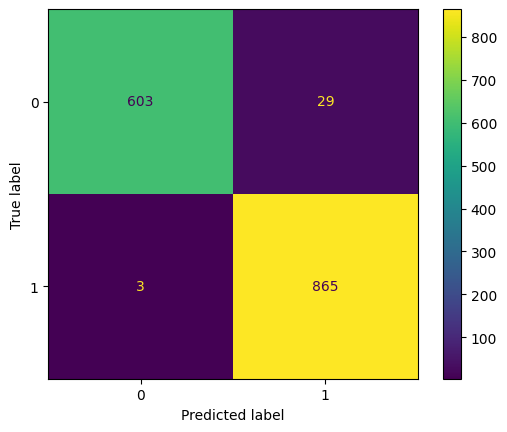

In [ ]:
C= metrics.confusion_matrix(d_test,ypred)
print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
sensitivity= C[0,0]/ np.sum(C[0,:]) *100
specificity= C[1,1]/ np.sum(C[1,:]) *100
print(f'Accuracy:{accuracy:.3f}%')
print(f'Sensitivity:{sensitivity:.3f}%')
print(f'Specificity:{specificity:.3f}%')
disp= metrics.ConfusionMatrixDisplay(C)
disp.plot()
plt.show()